## Exploratory Data Analysis

## Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for the notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
# Replace 'your_dataset.csv' with your actual file path
df = pd.read_csv('data/features/fma/fma_3sec_features.csv')

# Display the first few rows
display(df.head())

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,track_id,genre_top_id,genre_top,tempo,chroma_cqt_mean_0,chroma_cqt_mean_1,chroma_cqt_mean_2,...,mfcc_9_mean,mfcc_9_var,mfcc_10_mean,mfcc_10_var,mfcc_11_mean,mfcc_11_var,mfcc_12_mean,mfcc_12_var,mfcc_13_mean,mfcc_13_var
0,0,0.0,NaN,1400,17,Folk,107.666016,0.184987,0.262701,0.923105,...,-2.423363,129.327552,-4.701532,84.889724,-8.684305,71.035430,-2.355311,57.440479,-11.786307,59.422977
1,1,1.0,NaN,1401,17,Folk,107.666016,0.268611,0.273160,0.738287,...,1.796379,156.384475,8.131128,117.945138,2.342754,76.846771,-2.591171,44.182737,-4.171655,58.262290
2,2,2.0,NaN,1402,17,Folk,112.347147,0.338778,0.313925,0.362810,...,0.052514,62.732045,9.425413,85.496662,-1.666804,101.296117,-3.308932,57.531285,-4.994349,98.382535
3,3,3.0,NaN,1403,17,Folk,107.666016,0.230920,0.205028,0.790822,...,4.490312,131.050713,4.591160,127.001600,-4.244418,62.718070,-0.918658,73.108830,-2.926894,68.951556
4,4,4.0,NaN,1404,17,Folk,73.828125,0.360296,0.316228,0.501986,...,3.680351,70.131291,3.917576,91.722851,-7.273905,80.758939,-2.892184,95.293446,-6.917620,37.915449


## Dataset Info

In [16]:
print("--- Dataset Info ---")
display(df.info())

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only print columns that actually have missing data

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 97 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0.2             20000 non-null  int64  
 1   Unnamed: 0.1             11930 non-null  float64
 2   Unnamed: 0               0 non-null      float64
 3   track_id                 20000 non-null  int64  
 4   genre_top_id             20000 non-null  int64  
 5   genre_top                20000 non-null  object 
 6   tempo                    20000 non-null  float64
 7   chroma_cqt_mean_0        20000 non-null  float64
 8   chroma_cqt_mean_1        20000 non-null  float64
 9   chroma_cqt_mean_2        20000 non-null  float64
 10  chroma_cqt_mean_3        20000 non-null  float64
 11  chroma_cqt_mean_4        20000 non-null  float64
 12  chroma_cqt_mean_5        20000 non-null  float64
 13  chroma_cqt_mean_6        20000 non-null  float64
 14  c

None


--- Summary Statistics ---


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,track_id,genre_top_id,tempo,chroma_cqt_mean_0,chroma_cqt_mean_1,chroma_cqt_mean_2,chroma_cqt_mean_3,...,mfcc_9_mean,mfcc_9_var,mfcc_10_mean,mfcc_10_var,mfcc_11_mean,mfcc_11_var,mfcc_12_mean,mfcc_12_var,mfcc_13_mean,mfcc_13_var
count,20000.000000,11930.00000,0.0,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,5964.50000,NaN,8.484642e+05,168.750000,127.429548,0.445107,0.408298,0.463690,0.405628,...,-3.145228,76.798813,2.240304,72.489498,-3.534056,68.412543,0.870360,64.207113,-3.754568,63.300185
std,5773.647028,3444.03869,NaN,4.369340e+05,403.132191,22.820601,0.214463,0.202048,0.213770,0.203178,...,8.849015,54.610710,8.577774,50.346741,8.292485,47.799910,7.643023,44.416607,7.264292,46.440520
min,0.000000,0.00000,NaN,1.400000e+03,2.000000,41.677167,0.000000,0.000000,0.000000,0.000000,...,-59.320221,0.000000,-38.423648,0.000000,-58.534418,0.000000,-42.745162,0.000000,-49.034531,0.000000
25%,4999.750000,2982.25000,NaN,5.029672e+05,11.500000,112.347147,0.284047,0.253367,0.305642,0.250355,...,-8.393881,42.424471,-2.739042,40.386636,-8.221509,38.810483,-3.336148,37.461489,-7.956907,36.523316
50%,9999.500000,5964.50000,NaN,9.029195e+05,16.000000,123.046875,0.422470,0.388729,0.447367,0.387486,...,-2.811457,61.807973,2.960544,59.176533,-2.907813,55.727498,1.535237,53.124201,-3.322734,51.963213
75%,14999.250000,8946.75000,NaN,1.239349e+06,25.250000,143.554688,0.590991,0.542542,0.606333,0.540289,...,2.471998,94.776640,7.821274,89.640863,1.781408,83.206479,5.743829,77.351070,0.750649,75.947417
max,19999.000000,11929.00000,NaN,1.550669e+06,1235.000000,258.398438,1.000000,1.000000,1.000000,1.000000,...,43.463370,1449.372045,47.661780,1212.020327,52.709963,1218.420385,48.727472,901.795327,45.600758,1362.564966



--- Missing Values Check ---
Unnamed: 0.1     8070
Unnamed: 0      20000
dtype: int64


## Class Distribution

/tmp/ipykernel_10509/3349669903.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="genre_top", palette='viridis')


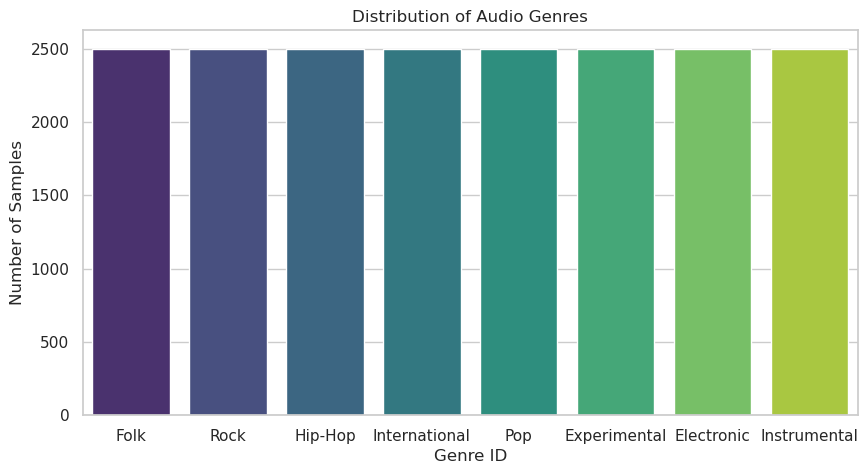

In [17]:
target_col = 'genre_top_id' # Change this if your label column has a different name

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="genre_top", palette='viridis')
plt.title('Distribution of Audio Genres')
plt.xlabel('Genre ID')
plt.ylabel('Number of Samples')
plt.show()

## Feature Distribution

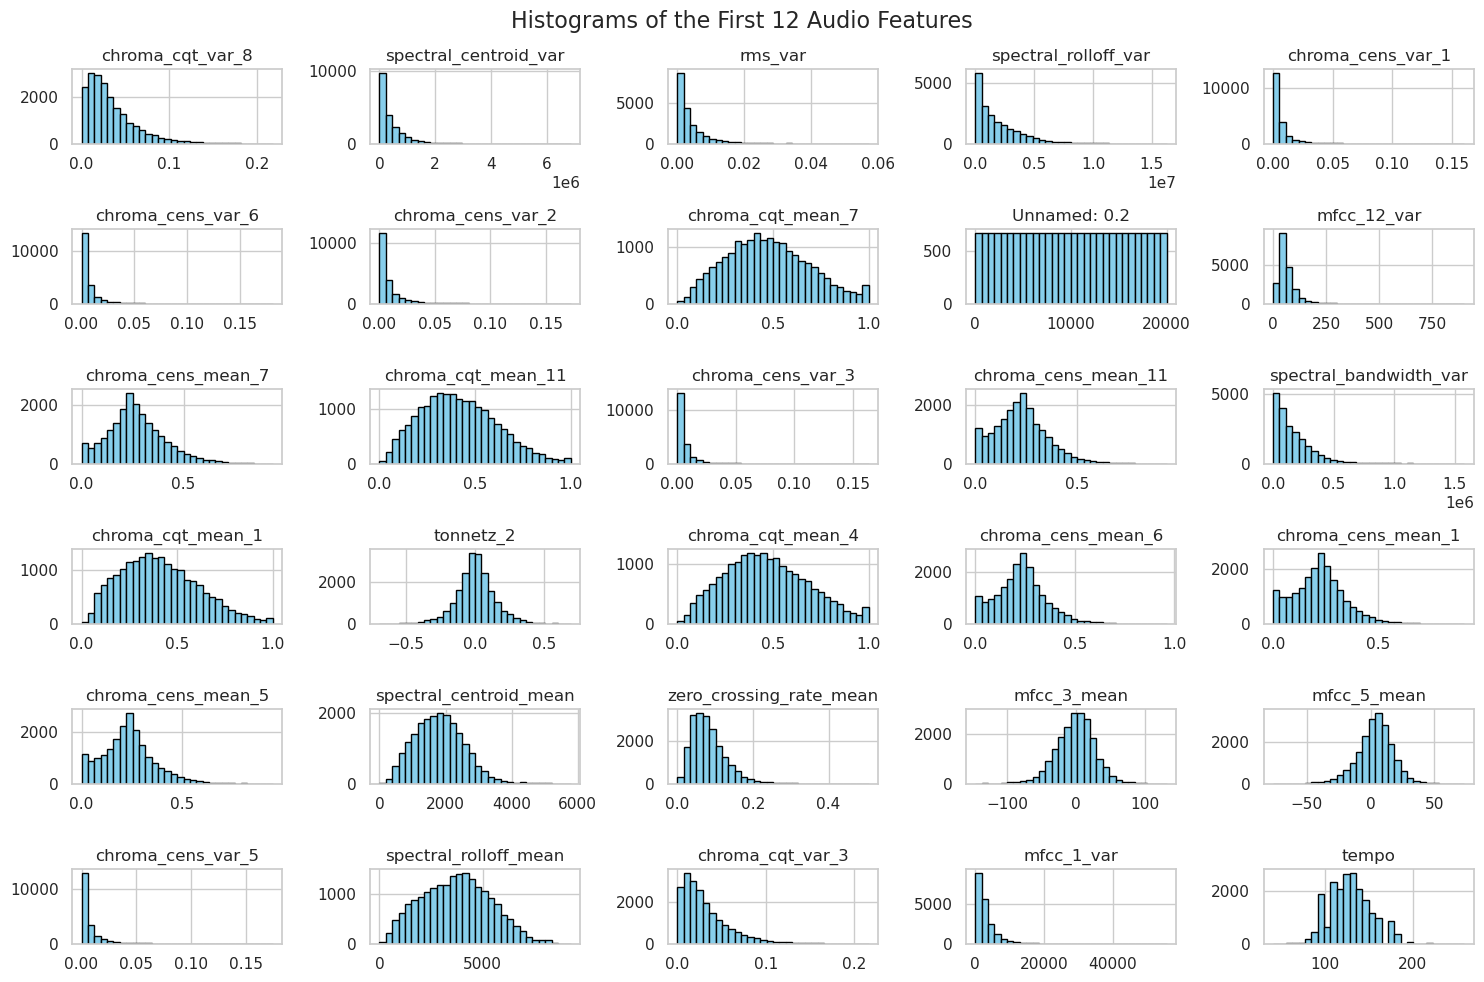

In [18]:
# Select only the numerical feature columns (exclude the target label)
feature_cols = df.drop(columns=[target_col, "Unnamed: 0.1", "Unnamed: 0", "track_id", "genre_top_id", "genre_top"]).select_dtypes(include=[np.number]).columns

# Safely select random 30 features to avoid overloading the notebook output
random_features = np.random.choice(feature_cols, size=30, replace=False) 

df[random_features].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of the First 12 Audio Features', fontsize=16)
plt.tight_layout()
plt.show()

## Feature Correlation

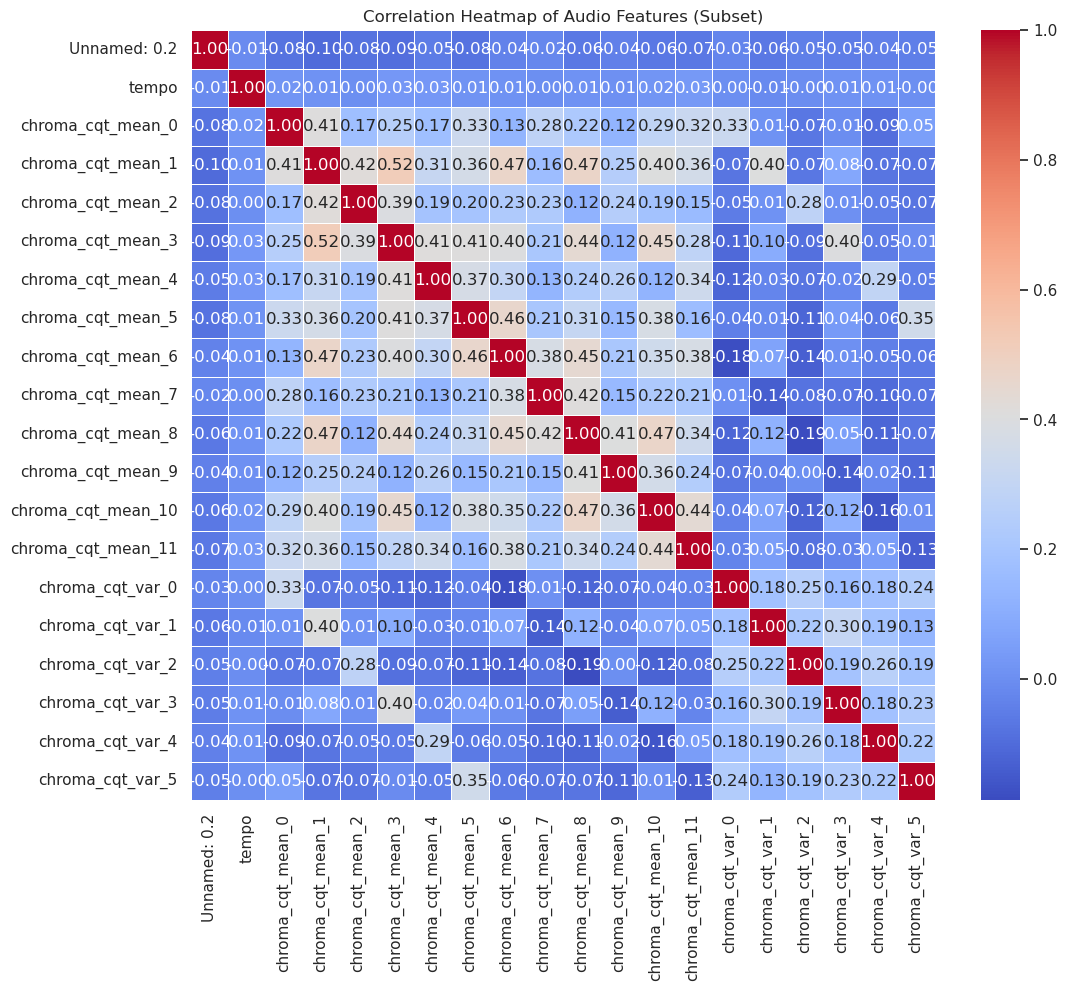

In [19]:
# Calculate the correlation matrix for a subset of features (e.g., first 15)
# Plotting a 1000x1000 correlation matrix is unreadable, so we subset
subset_features = feature_cols[:20]
corr_matrix = df[subset_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features (Subset)')
plt.show()

## Box Plot Feature Distribution

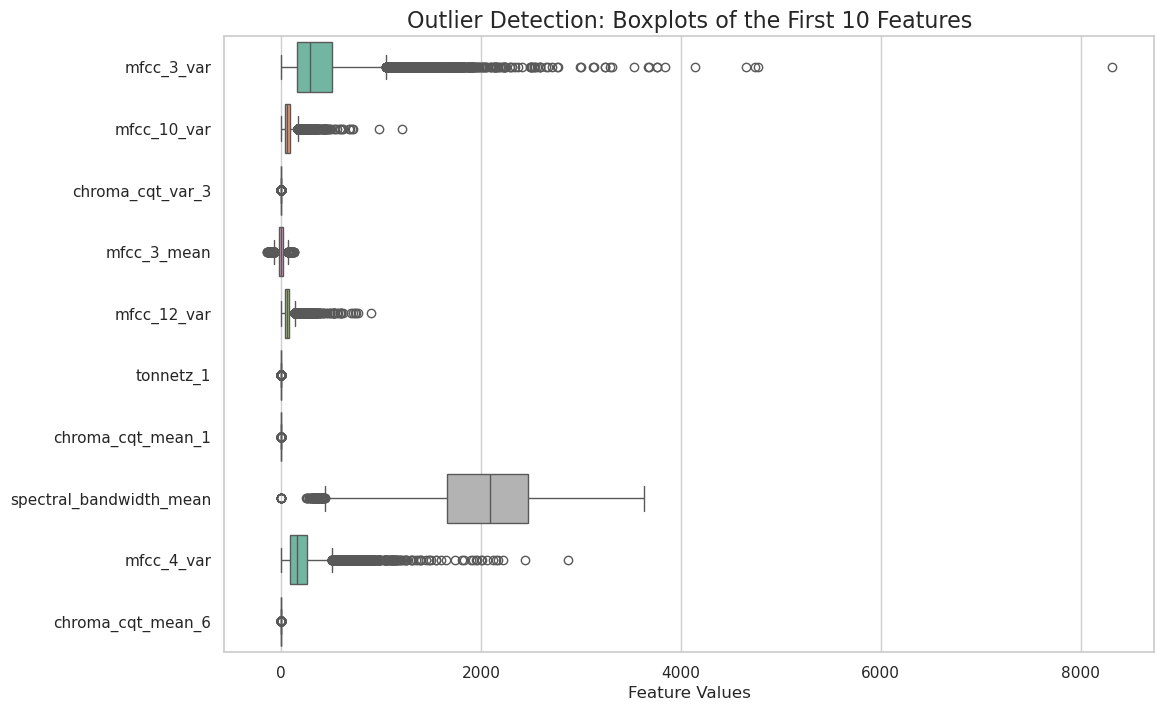

/tmp/ipykernel_10509/2278189902.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feature_to_examine, palette="viridis")


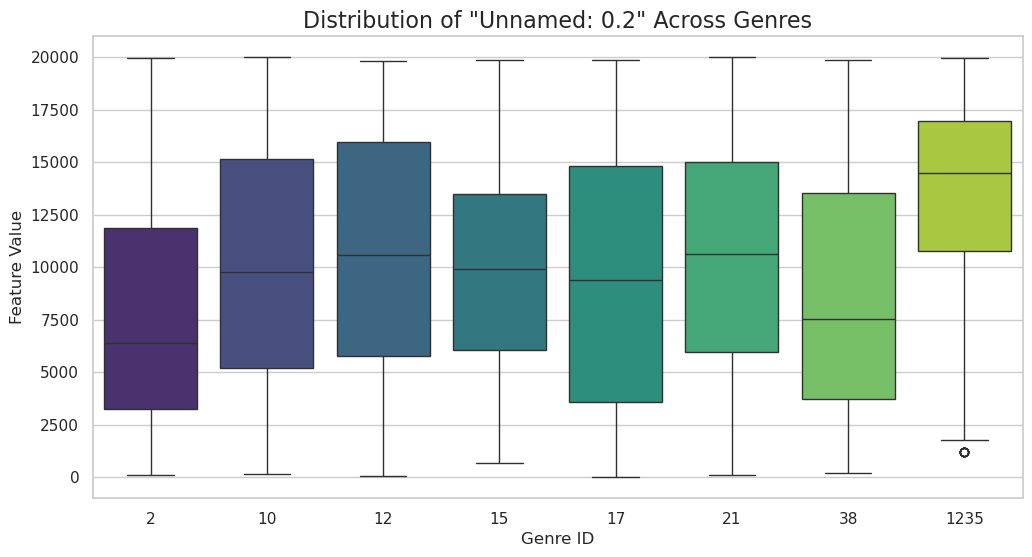

In [6]:
# --- 1. General Outlier Detection across Features ---
# Select a subset of features to keep the plot readable (e.g., the first 10)
num_features = min(10, len(feature_cols))
random_features = np.random.choice(feature_cols, size=num_features, replace=False)

plt.figure(figsize=(12, 8))
# orient="h" makes it horizontal, which is easier to read for many features
sns.boxplot(data=df[random_features], orient="h", palette="Set2")
plt.title('Outlier Detection: Boxplots of the First 10 Features', fontsize=16)
plt.xlabel('Feature Values')
plt.show()

# --- 2. Feature Distribution by Genre ---
# Let's look at how the very first feature varies across your different genres.
# (You can change feature_cols[0] to any specific column name you want to investigate)
feature_to_examine = feature_cols[0] 

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x=target_col, y=feature_to_examine, palette="viridis")
plt.title(f'Distribution of "{feature_to_examine}" Across Genres', fontsize=16)
plt.xlabel('Genre ID')
plt.ylabel('Feature Value')
plt.show()

## Model Tests + Evaluation

## Utilty Functions

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Import the models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

def evaluate_traditional_models(csv_path, target_column="genre_top_id"):
    # 1. Load the DataFrame
    print("Loading data...")
    df = pd.read_csv(csv_path)
    
    # Separate features (X) and labels (y)
    X = df.drop(columns=[target_column, "Unnamed: 0.1", "Unnamed: 0", "track_id", "genre_top_id", "genre_top"])
    y = df[target_column]
    
    # 2. Split into train and test sets (80/20 ratio)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 3. Scale the features (CRITICAL for KNN, SVM, Logistic Regression, and MLP)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Initialize the models
    models = {
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
        "Support Vector Machine": SVC(max_iter=-1, kernel='rbf', random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
        "Multilayer Perceptron": MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
    }
    
    # Dictionary to store accuracy scores for a final comparison chart
    accuracy_scores = {}

    # 5. Train and Evaluate each model
    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}...")
        
        # Train the model (Random Forest doesn't strict need scaling, but it doesn't hurt it)
        model.fit(X_train_scaled, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test_scaled)
        
        # Print Classification Report (Precision, Recall, F1-Score)
        print(f"\nClassification Report for {name}:")
        report = classification_report(y_test, y_pred)
        print(report)
        
        # Save accuracy for the final bar chart
        accuracy = model.score(X_test_scaled, y_test)
        accuracy_scores[name] = accuracy
        
        # Plot Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    # 6. Final Comparison Bar Chart
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    for i, v in enumerate(accuracy_scores.values()):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    plt.show()

# To run the script, just call the function with your dataset path:
# evaluate_traditional_models("path_to_your_features.csv", target_column="genre_id")

## Evaluate Training Performance

Loading data...

Training K-Nearest Neighbors...

Classification Report for K-Nearest Neighbors:
               precision    recall  f1-score   support

   Electronic       0.78      0.82      0.80       500
 Experimental       0.81      0.78      0.80       500
         Folk       0.68      0.78      0.72       500
      Hip-Hop       0.80      0.91      0.85       500
 Instrumental       0.84      0.70      0.76       500
International       0.78      0.83      0.80       500
          Pop       0.78      0.66      0.71       500
         Rock       0.83      0.80      0.81       500

     accuracy                           0.78      4000
    macro avg       0.79      0.78      0.78      4000
 weighted avg       0.79      0.78      0.78      4000



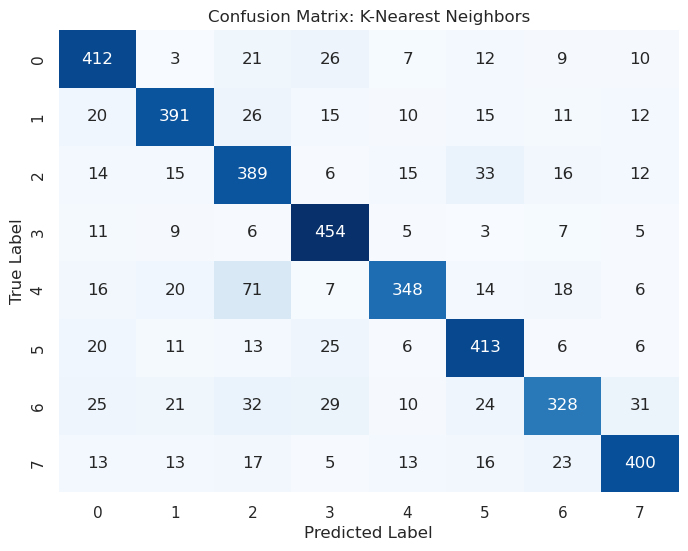


Training Support Vector Machine...

Classification Report for Support Vector Machine:
               precision    recall  f1-score   support

   Electronic       0.72      0.70      0.71       500
 Experimental       0.76      0.63      0.69       500
         Folk       0.67      0.78      0.72       500
      Hip-Hop       0.72      0.81      0.76       500
 Instrumental       0.71      0.80      0.75       500
International       0.76      0.75      0.75       500
          Pop       0.67      0.50      0.58       500
         Rock       0.70      0.73      0.71       500

     accuracy                           0.71      4000
    macro avg       0.71      0.71      0.71      4000
 weighted avg       0.71      0.71      0.71      4000



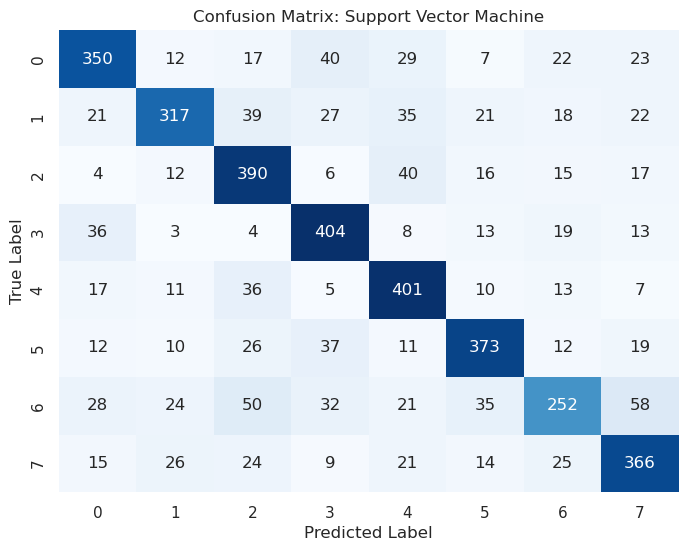


Training Random Forest...

Classification Report for Random Forest:
               precision    recall  f1-score   support

   Electronic       0.83      0.76      0.79       500
 Experimental       0.88      0.72      0.79       500
         Folk       0.68      0.82      0.75       500
      Hip-Hop       0.75      0.88      0.81       500
 Instrumental       0.78      0.86      0.82       500
International       0.75      0.82      0.78       500
          Pop       0.84      0.57      0.68       500
         Rock       0.77      0.79      0.78       500

     accuracy                           0.78      4000
    macro avg       0.79      0.78      0.77      4000
 weighted avg       0.79      0.78      0.77      4000



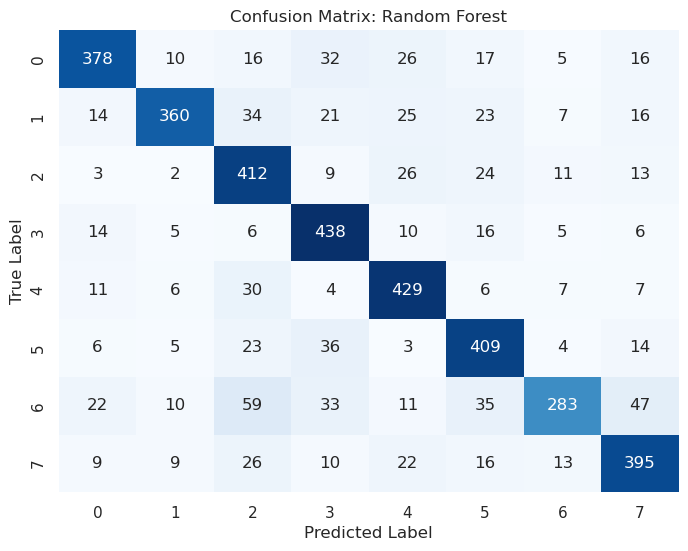


Training Logistic Regression...

Classification Report for Logistic Regression:
               precision    recall  f1-score   support

   Electronic       0.45      0.43      0.44       500
 Experimental       0.39      0.28      0.33       500
         Folk       0.49      0.58      0.53       500
      Hip-Hop       0.53      0.63      0.57       500
 Instrumental       0.51      0.63      0.56       500
International       0.45      0.42      0.44       500
          Pop       0.32      0.16      0.21       500
         Rock       0.50      0.64      0.56       500

     accuracy                           0.47      4000
    macro avg       0.46      0.47      0.46      4000
 weighted avg       0.46      0.47      0.46      4000



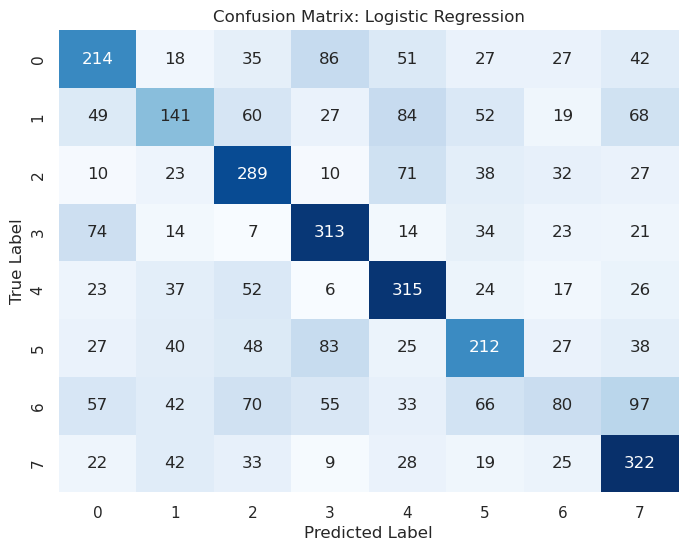


Training Multilayer Perceptron...

Classification Report for Multilayer Perceptron:
               precision    recall  f1-score   support

   Electronic       0.66      0.64      0.65       500
 Experimental       0.63      0.61      0.62       500
         Folk       0.63      0.66      0.64       500
      Hip-Hop       0.70      0.73      0.71       500
 Instrumental       0.65      0.65      0.65       500
International       0.67      0.70      0.69       500
          Pop       0.53      0.51      0.52       500
         Rock       0.70      0.68      0.69       500

     accuracy                           0.65      4000
    macro avg       0.65      0.65      0.65      4000
 weighted avg       0.65      0.65      0.65      4000



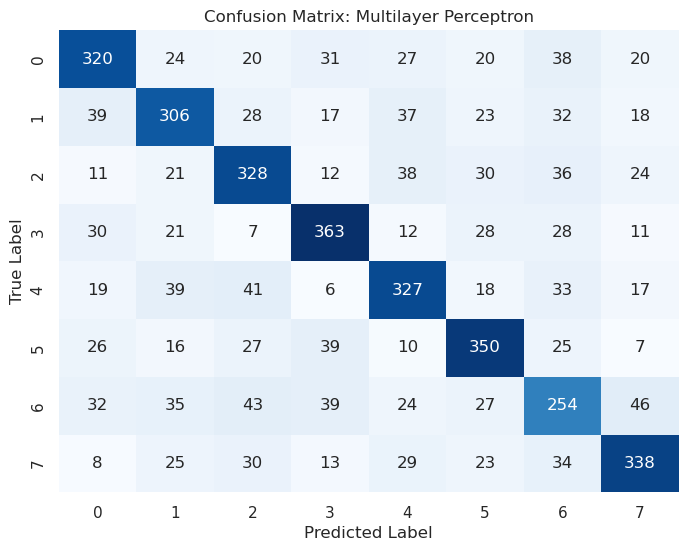

/tmp/ipykernel_10509/3933663717.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')


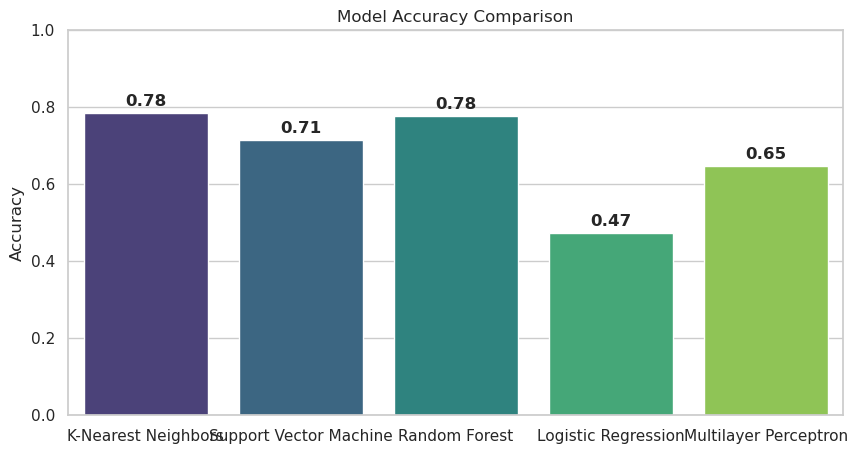

In [21]:
evaluate_traditional_models("data/features/fma/fma_3sec_features.csv", target_column="genre_top")